# Looking at SKM-TEA Predictions

In [1]:
# Imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
import json
import pandas as pd
import torch
import sys

In [8]:
# functions to take json file and return array of dice scores, or return hausdorff distance
def get_dice_score_and_filename(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Dice scores from "metric_per_case"
    dice_scores = [
        case["metrics"]["1"]["Dice"] for case in data["metric_per_case"]
    ]

    # Extract filenames from "metric_per_case"
    filenames = [
        os.path.basename(case["reference_file"]) for case in data["metric_per_case"]
    ]


    return dice_scores, filenames

## Paths

In [39]:
# annotation of external data containing pathology info
ann_dir_path = '/scratch/scojm/project/tear_detection/data/qdess/v1-release/annotations/v1.0.0/'

# path to predicted segmentation masks (zscore)
pred_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/zscore_preds_all_skmtea'

In [40]:
# load dice scores
json_path = os.path.join(pred_path, 'summary.json')
dice_scores, filenames = get_dice_score_and_filename(json_path)

In [41]:
df = pd.DataFrame({'filename': filenames, 'dice_score': dice_scores})

In [42]:
df.head()

,filename,dice_score
0,SKMTEA_001.nii.gz,0.802798
1,SKMTEA_002.nii.gz,0.805975
2,SKMTEA_003.nii.gz,0.824203
3,SKMTEA_004.nii.gz,0.797574
4,SKMTEA_005.nii.gz,0.823736


In [78]:
# have entire function that will take in path to json file
# and return dataframe with filename and number of meniscal pathologies
def get_pathology_count(json_file):

    # Open and load the JSON file
    with open(ann_dir_path + json_file, "r") as file:
        data = json.load(file)

    # Access each part of the JSON structure
    info = data["info"]
    categories = data["categories"]
    images = data["images"]
    annotations = data["annotations"]

    # get paths from image data
    ims_df = pd.DataFrame(images)
    ims_df.head()

    # paths of all images in the split the json file refers to
    image_paths = ims_df['file_name'].to_numpy()

    # # Mapping dictionaries for cross-referencing filename from imageid
    id_to_filename = dict(zip(ims_df["id"], ims_df["file_name"]))

    # as a dataframe
    categories_df = pd.DataFrame(categories)

    # Mapping dictionaries for cross-referencing
    id_to_name = dict(zip(categories_df["id"], categories_df["name"]))
    id_to_supercategory = dict(zip(categories_df["id"], categories_df["supercategory"]))

    anns_df = pd.DataFrame(annotations)

    # filter by meniscus
    menisc_anns_df = anns_df[anns_df['tissue_id'] == 1].reset_index(drop=True)
    print(f'Number of meniscus annotations: {len(menisc_anns_df)}')
    menisc_anns_df.head()

    # get list of image ids with meniscus pathology
    pathology_im_ids = menisc_anns_df['image_id'].to_numpy()

    # Initialise a DataFrame with image IDs and zero counts
    im_ids = ims_df['id'].to_numpy()
    pathology_count_df = pd.DataFrame({'image_id': im_ids, 'num_pathologies': 0})

    # Add count to image for each pathology found in the pathology list
    for pid in pathology_im_ids:
        if pid in pathology_count_df['image_id'].values:
            pathology_count_df.loc[pathology_count_df['image_id'] == pid, 'num_pathologies'] += 1

    # create column with filename from image id
    pathology_count_df['filename'] = pathology_count_df['image_id'].map(id_to_filename)

    # remove image_id column
    pathology_count_df = pathology_count_df.drop(columns=['image_id'])

    # make filename the first column
    cols = pathology_count_df.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    pathology_count_df = pathology_count_df[cols]

    return pathology_count_df

In [79]:
train_pathology_count_df = get_pathology_count('train.json')
train_pathology_count_df.head()

Number of meniscus annotations: 47


,filename,num_pathologies
0,MTR_001.h5,0
1,MTR_008.h5,0
2,MTR_010.h5,0
3,MTR_015.h5,0
4,MTR_016.h5,1


In [80]:
val_pathology_count_df = get_pathology_count('val.json')
val_pathology_count_df.head()

Number of meniscus annotations: 30


,filename,num_pathologies
0,MTR_013.h5,0
1,MTR_023.h5,2
2,MTR_026.h5,0
3,MTR_037.h5,1
4,MTR_038.h5,0


In [81]:
test_pathology_count_df = get_pathology_count('test.json')
test_pathology_count_df.head()

Number of meniscus annotations: 31


,filename,num_pathologies
0,MTR_005.h5,1
1,MTR_006.h5,1
2,MTR_030.h5,3
3,MTR_034.h5,0
4,MTR_048.h5,0


### Combine annotations

In [89]:
all_path_count_df = pd.concat([train_pathology_count_df, val_pathology_count_df, test_pathology_count_df], ignore_index=True)
print(f'Total number of images: {len(all_path_count_df)}')

# order by filename
all_path_count_df = all_path_count_df.sort_values(by='filename').reset_index(drop=True)

# add corresponding skmtea nnunet filename
all_path_count_df = all_path_count_df.reset_index(drop=True)
all_path_count_df['skmtea_filename'] = (
    'SKMTEA_' + (all_path_count_df.index + 1).astype(str).str.zfill(3) + '.nii.gz'
)

all_path_count_df.head()

Total number of images: 155


,filename,num_pathologies,skmtea_filename
0,MTR_001.h5,0,SKMTEA_001.nii.gz
1,MTR_005.h5,1,SKMTEA_002.nii.gz
2,MTR_006.h5,1,SKMTEA_003.nii.gz
3,MTR_008.h5,0,SKMTEA_004.nii.gz
4,MTR_010.h5,0,SKMTEA_005.nii.gz


In [90]:
# add dice scores by matching skmtea filename to df
all_path_count_df['dice_score'] = all_path_count_df['skmtea_filename'].map(df.set_index('filename')['dice_score'])

all_path_count_df.head()

,filename,num_pathologies,skmtea_filename,dice_score
0,MTR_001.h5,0,SKMTEA_001.nii.gz,0.802798
1,MTR_005.h5,1,SKMTEA_002.nii.gz,0.805975
2,MTR_006.h5,1,SKMTEA_003.nii.gz,0.824203
3,MTR_008.h5,0,SKMTEA_004.nii.gz,0.797574
4,MTR_010.h5,0,SKMTEA_005.nii.gz,0.823736


In [91]:
ims_with_pathology = all_path_count_df[all_path_count_df['num_pathologies'] > 0].reset_index(drop=True)
ims_without_pathology = all_path_count_df[all_path_count_df['num_pathologies'] == 0].reset_index(drop=True)

In [92]:
print("All Images with Pathology:")
ims_with_pathology

All Images with Pathology:


,filename,num_pathologies,skmtea_filename,dice_score
0,MTR_005.h5,1,SKMTEA_002.nii.gz,0.805975
1,MTR_006.h5,1,SKMTEA_003.nii.gz,0.824203
2,MTR_016.h5,1,SKMTEA_008.nii.gz,0.777880
3,MTR_019.h5,1,SKMTEA_010.nii.gz,0.807918
4,MTR_020.h5,2,SKMTEA_011.nii.gz,0.749756
...,...,...,...,...
64,MTR_241.h5,1,SKMTEA_150.nii.gz,0.706206
65,MTR_244.h5,1,SKMTEA_152.nii.gz,0.857262
66,MTR_245.h5,1,SKMTEA_153.nii.gz,0.725464
67,MTR_248.h5,1,SKMTEA_154.nii.gz,0.808828


In [94]:
print("All Images without Pathology:")
ims_without_pathology

All Images without Pathology:


,filename,num_pathologies,skmtea_filename,dice_score
0,MTR_001.h5,0,SKMTEA_001.nii.gz,0.802798
1,MTR_008.h5,0,SKMTEA_004.nii.gz,0.797574
2,MTR_010.h5,0,SKMTEA_005.nii.gz,0.823736
3,MTR_013.h5,0,SKMTEA_006.nii.gz,0.835576
4,MTR_015.h5,0,SKMTEA_007.nii.gz,0.792418
...,...,...,...,...
81,MTR_232.h5,0,SKMTEA_144.nii.gz,0.839719
82,MTR_233.h5,0,SKMTEA_145.nii.gz,0.832940
83,MTR_235.h5,0,SKMTEA_146.nii.gz,0.797404
84,MTR_237.h5,0,SKMTEA_148.nii.gz,0.781798


In [95]:
# Get mean and std of dice scores for images with pathology
mean_dice_pathology = ims_with_pathology['dice_score'].mean()
std_dice_pathology = ims_with_pathology['dice_score'].std()
print(f"Mean Dice Coefficient for Images with Pathology: {mean_dice_pathology} ± {std_dice_pathology}")

# Get mean and std of dice scores for images without pathology
mean_dice_no_pathology = ims_without_pathology['dice_score'].mean()
std_dice_no_pathology = ims_without_pathology['dice_score'].std()
print(f"Mean Dice Coefficient for Images without Pathology: {mean_dice_no_pathology} ± {std_dice_no_pathology}")

Mean Dice Coefficient for Images with Pathology: 0.7901190800597354 ± 0.04485178888681295
Mean Dice Coefficient for Images without Pathology: 0.792797325930075 ± 0.03837330991773893


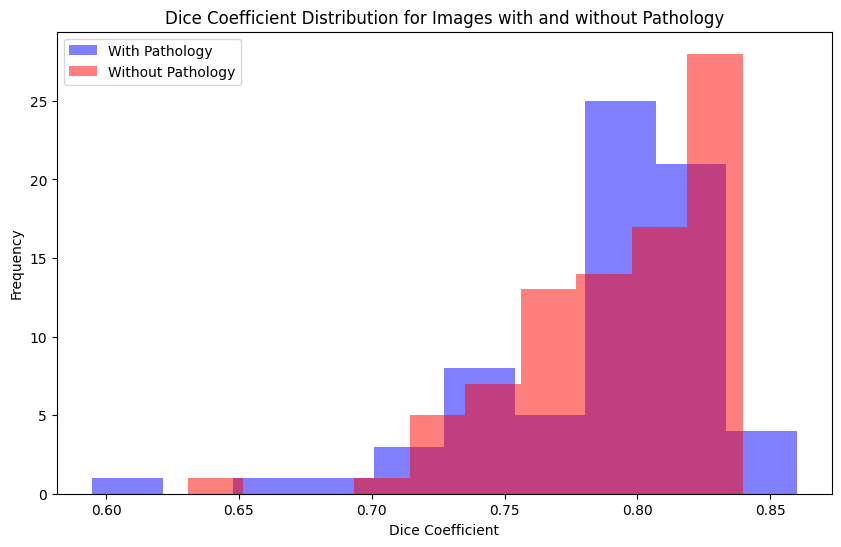

In [97]:
# Plot histograms of dice scores with and without pathology for comparison
plt.figure(figsize=(10, 6))
plt.hist(ims_with_pathology['dice_score'], bins=10, alpha=0.5, color='blue', label='With Pathology')
plt.hist(ims_without_pathology['dice_score'], bins=10, alpha=0.5, color='red', label='Without Pathology')
plt.xlabel('Dice Coefficient')
plt.ylabel('Frequency')
plt.title('Dice Coefficient Distribution for Images with and without Pathology')
plt.legend()
plt.show()

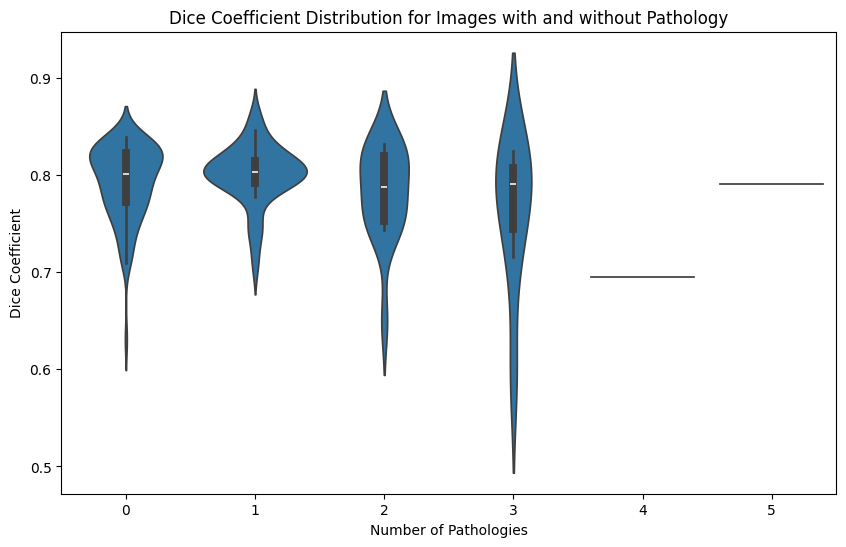

In [98]:
# plot violin plots of with and without pathology using seaborn
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(data=all_path_count_df, x='num_pathologies', y='dice_score')
plt.xlabel('Number of Pathologies')
plt.ylabel('Dice Coefficient')
plt.title('Dice Coefficient Distribution for Images with and without Pathology')

# save plot
plt.savefig('dice_vs_pathology_valid.pdf')
plt.show()

In [100]:
# check dice scores to see if they are consistent statistically
# use t-test for this
from scipy.stats import ttest_ind, mannwhitneyu

t_stat, p_val = ttest_ind(ims_with_pathology['dice_score'], ims_without_pathology['dice_score'], equal_var=False)
print(f"t-statistic: {t_stat}, p-value: {p_val}")

# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(ims_with_pathology['dice_score'], ims_without_pathology['dice_score'])
print(f"U-statistic: {u_stat}, p-value: {p_val}")

t-statistic: -0.3937020096999563, p-value: 0.6944255326562279
U-statistic: 2850.0, p-value: 0.6748870917881218


In [103]:
# check across different number of pathologies
ims_zero_path = all_path_count_df[all_path_count_df['num_pathologies'] == 0].reset_index(drop=True)
ims_one_path = all_path_count_df[all_path_count_df['num_pathologies'] == 1].reset_index(drop=True)
ims_two_path = all_path_count_df[all_path_count_df['num_pathologies'] == 2].reset_index(drop=True)
ims_three_path = all_path_count_df[all_path_count_df['num_pathologies'] == 3].reset_index(drop=True)

# do mannwhitneyu test between each group
u_stat_0_1, p_val_0_1 = mannwhitneyu(ims_zero_path['dice_score'], ims_one_path['dice_score'])
u_stat_0_2, p_val_0_2 = mannwhitneyu(ims_zero_path['dice_score'], ims_two_path['dice_score'])
u_stat_0_3, p_val_0_3 = mannwhitneyu(ims_zero_path['dice_score'], ims_three_path['dice_score'])
u_stat_1_2, p_val_1_2 = mannwhitneyu(ims_one_path['dice_score'], ims_two_path['dice_score'])
u_stat_1_3, p_val_1_3 = mannwhitneyu(ims_one_path['dice_score'], ims_three_path['dice_score'])
u_stat_2_3, p_val_2_3 = mannwhitneyu(ims_two_path['dice_score'], ims_three_path['dice_score'])

print(f"U-statistic (0 vs 1): {u_stat_0_1}, p-value: {p_val_0_1}")
print(f"U-statistic (0 vs 2): {u_stat_0_2}, p-value: {p_val_0_2}")
print(f"U-statistic (0 vs 3): {u_stat_0_3}, p-value: {p_val_0_3}")
print(f"U-statistic (1 vs 2): {u_stat_1_2}, p-value: {p_val_1_2}")
print(f"U-statistic (1 vs 3): {u_stat_1_3}, p-value: {p_val_1_3}")
print(f"U-statistic (2 vs 3): {u_stat_2_3}, p-value: {p_val_2_3}")

U-statistic (0 vs 1): 1736.0, p-value: 0.574070434475608
U-statistic (0 vs 2): 783.0, p-value: 0.3845463254777608
U-statistic (0 vs 3): 428.0, p-value: 0.2633024448381452
U-statistic (1 vs 2): 406.0, p-value: 0.2943777743837179
U-statistic (1 vs 3): 220.0, p-value: 0.2232611612749829
U-statistic (2 vs 3): 71.0, p-value: 0.6967970185092274


### No meaningful difference in dice scores 